LOAD CSV IN PYTHON

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the logs
df = pd.read_csv("/content/access_logs (1).csv")

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Extract hour for time-based analysis
df['hour'] = df['timestamp'].dt.hour

print(df.head())
print(df.info())


                   timestamp  user_id         action     resource   status  \
0 2025-11-16 09:29:32.758486   user_6          login  public_page  success   
1 2025-11-16 08:02:23.758557   user_2      view_page    dashboard  success   
2 2025-11-16 00:28:12.758593   user_3         logout  config.yaml  success   
3 2025-11-16 06:24:16.758622  user_15          login  public_page  success   
4 2025-11-16 01:23:33.758648  user_15  delete_record  admin_panel  success   

       ip_address  response_time_ms  hour  
0  212.151.92.169               236     9  
1  205.190.251.14               148     8  
2  115.142.194.75               255     0  
3   220.59.190.10               395     6  
4   29.66.111.215               384     1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   timestamp         500 non-null    datetime64[ns]
 

EVENTS PER USER

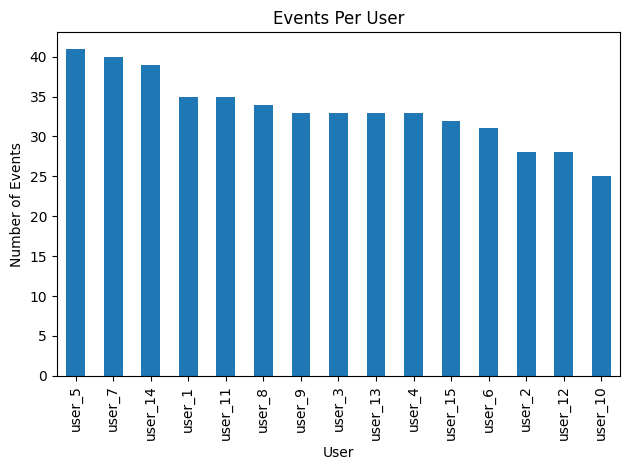

In [13]:
df['user_id'].value_counts().plot(kind='bar')
plt.title("Events Per User")
plt.xlabel("User")
plt.ylabel("Number of Events")
plt.tight_layout()
plt.savefig("events_per_user.png")
plt.show()


ACTIONS OVER TIME

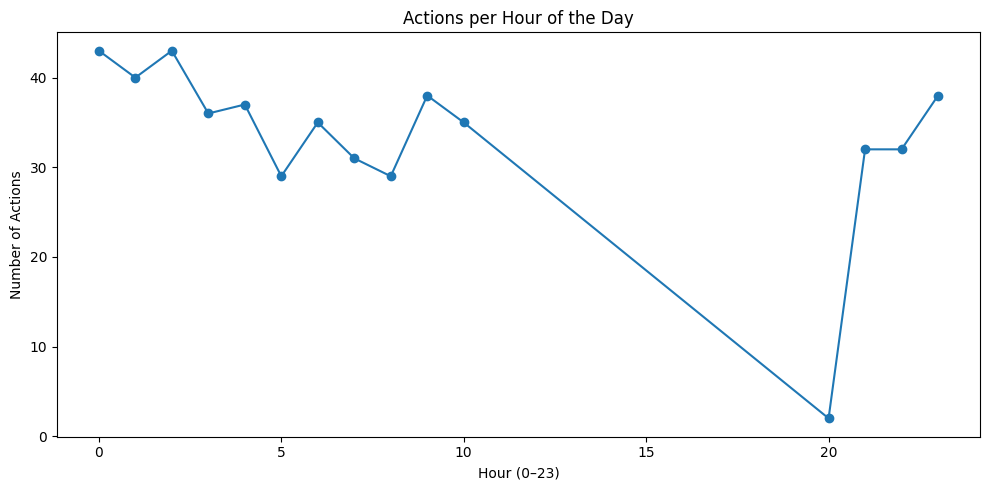

In [14]:
df.groupby('hour')['action'].count().plot(kind='line', marker='o', figsize=(10,5))
plt.title("Actions per Hour of the Day")
plt.xlabel("Hour (0–23)")
plt.ylabel("Number of Actions")
plt.tight_layout()
plt.savefig("actions_over_time.png")
plt.show()


ACTION PER USER

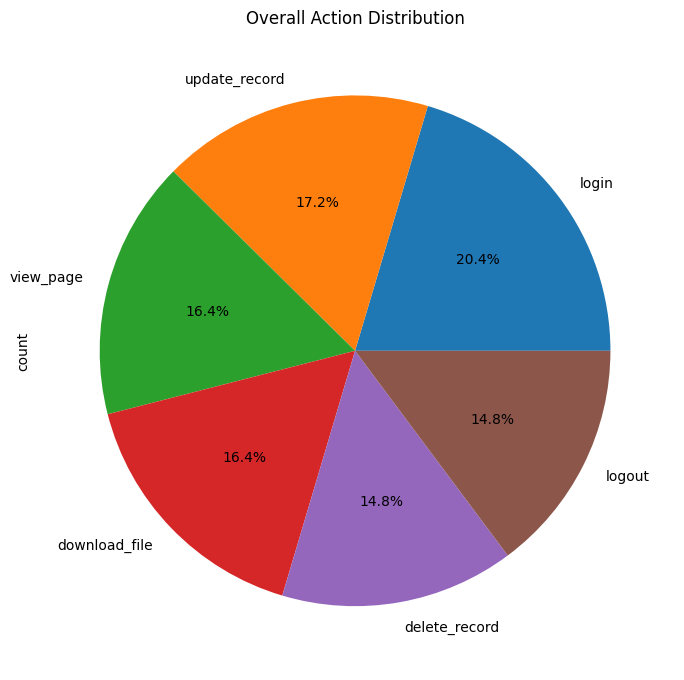

In [15]:
df['action'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(7,7))
plt.title("Overall Action Distribution")
plt.tight_layout()
plt.savefig("action_distribution.png")
plt.show()


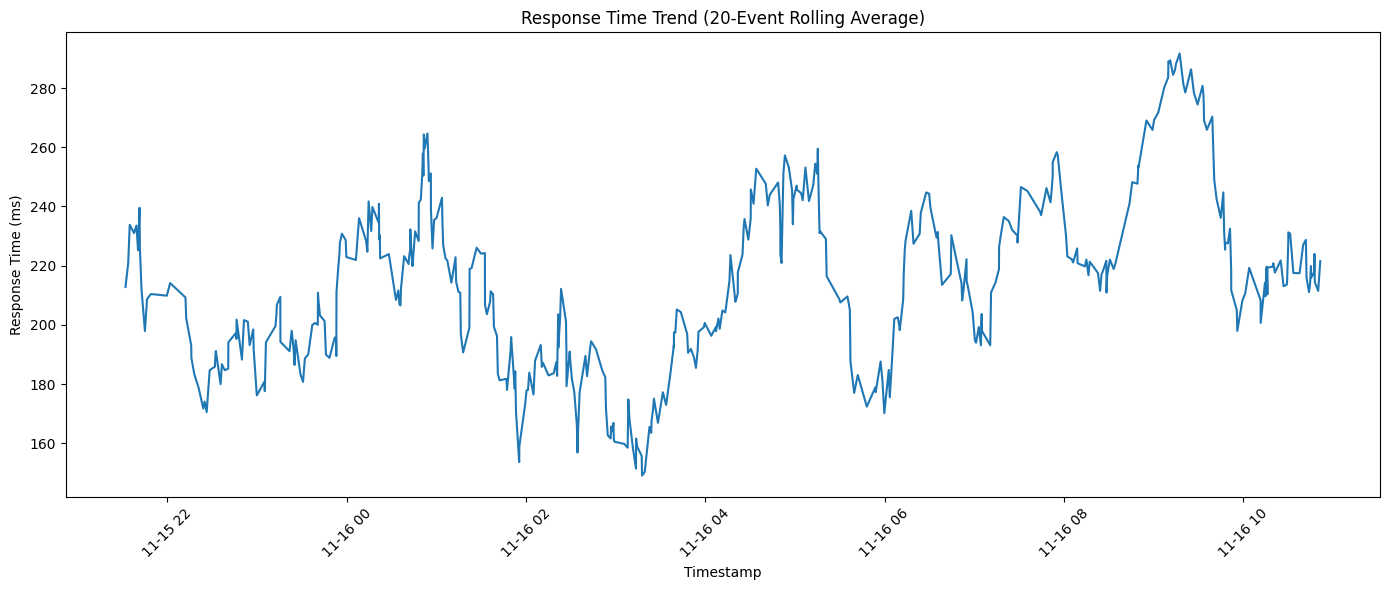

In [16]:
df_sorted = df.sort_values("timestamp")

df_sorted['rolling_mean'] = df_sorted['response_time_ms'].rolling(window=20).mean()

plt.figure(figsize=(14,6))
plt.plot(df_sorted['timestamp'], df_sorted['rolling_mean'])
plt.title("Response Time Trend (20-Event Rolling Average)")
plt.xlabel("Timestamp")
plt.ylabel("Response Time (ms)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("response_time_rolling.png")
plt.show()


 Failed Login Attempts Per User (or Over Time)

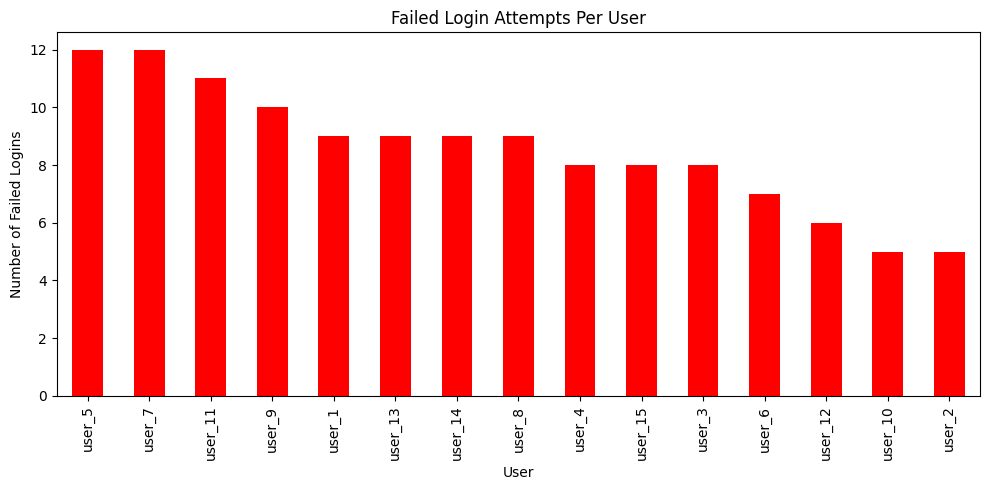

In [17]:
# Filter failed events
failed = df[df['status'] == 'failed']

plt.figure(figsize=(10,5))
failed['user_id'].value_counts().plot(kind='bar', color='red')
plt.title("Failed Login Attempts Per User")
plt.xlabel("User")
plt.ylabel("Number of Failed Logins")
plt.tight_layout()
plt.show()
